In [ ]:
import os, glob

# look in the usual places
candidates = (
    glob.glob("/content/*.zip")
    + glob.glob("/content/drive/MyDrive/**/*.zip", recursive=True)
)

print("ZIP candidates found:")
for p in candidates:
    print(p)



ZIP candidates found:
/content/drive/MyDrive/163/Yelp-JSON.zip


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os, zipfile, shutil

zip_path = "/content/drive/MyDrive/163/Yelp-JSON.zip"
out_dir  = "/content/Yelp_JSON"

os.makedirs(out_dir, exist_ok=True)

# This will now find the file if it's in your main Drive folder
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(out_dir)

# remove macOS metadata folder if it exists
macosx_path = os.path.join(out_dir, "__MACOSX")
if os.path.exists(macosx_path):
    shutil.rmtree(macosx_path)

print("Unzipped to:", out_dir)
print("Top-level:", os.listdir(out_dir))


Unzipped to: /content/Yelp_JSON
Top-level: ['Yelp JSON']


In [ ]:
import os
import glob

base = "/content/Yelp_JSON"  # where you extracted

print("Folders under base:")
for p in glob.glob(base + "/*"):
    print(p)

print("\nAll files under base (first 200):")
all_files = glob.glob(base + "/**/*", recursive=True)
all_files = [p for p in all_files if os.path.isfile(p)]
for p in all_files[:200]:
    print(p)

print("\nCount files:", len(all_files))


Folders under base:
/content/Yelp_JSON/Yelp JSON

All files under base (first 200):
/content/Yelp_JSON/Yelp JSON/Yelp Dataset Documentation & ToS copy.pdf
/content/Yelp_JSON/Yelp JSON/yelp_dataset.tar

Count files: 2


In [ ]:
import os, tarfile

tar_path = "/content/Yelp_JSON/Yelp JSON/yelp_dataset.tar"
out_dir  = "/content/Yelp_extracted"

os.makedirs(out_dir, exist_ok=True)

with tarfile.open(tar_path, "r:*") as tar:
    tar.extractall(path=out_dir)

print("Extracted TAR to:", out_dir)

# list extracted files
import glob
files = [p for p in glob.glob(out_dir + "/**/*", recursive=True) if os.path.isfile(p)]
print("Number of files:", len(files))
for p in files[:50]:
    print(p)

/tmp/ipykernel_9611/1518815979.py:9: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=out_dir)


Extracted TAR to: /content/Yelp_extracted
Number of files: 6
/content/Yelp_extracted/yelp_academic_dataset_checkin.json
/content/Yelp_extracted/yelp_academic_dataset_user.json
/content/Yelp_extracted/yelp_academic_dataset_tip.json
/content/Yelp_extracted/yelp_academic_dataset_review.json
/content/Yelp_extracted/Dataset_User_Agreement.pdf
/content/Yelp_extracted/yelp_academic_dataset_business.json


In [ ]:
import os, glob

base = "/content/Yelp_extracted"
all_files = [p for p in glob.glob(base + "/**/*", recursive=True) if os.path.isfile(p)]

def pick_file(keyword):
    matches = [p for p in all_files if keyword in os.path.basename(p).lower() and p.lower().endswith(".json")]
    return matches[0] if matches else None

business_path = pick_file("business")
review_path   = pick_file("review")
checkin_path  = pick_file("checkin")

print("business_path:", business_path)
print("review_path  :", review_path)
print("checkin_path :", checkin_path)

business_path: /content/Yelp_extracted/yelp_academic_dataset_business.json
review_path  : /content/Yelp_extracted/yelp_academic_dataset_review.json
checkin_path : /content/Yelp_extracted/yelp_academic_dataset_checkin.json


In [ ]:
import pandas as pd

business_df = pd.read_json(business_path, lines=True)
checkin_df  = pd.read_json(checkin_path, lines=True)

print("business:", business_df.shape)
print("checkin :", checkin_df.shape)


business: (150346, 14)
checkin : (131930, 2)


In [ ]:
import pandas as pd

def clean_business(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [c.strip().lower() for c in df.columns]

    # drop duplicates using business_id only (avoids dict hashing)
    if "business_id" in df.columns:
        df = df.drop_duplicates(subset=["business_id"])
    else:
        df = df.drop_duplicates()

    # required fields
    df = df.dropna(subset=["business_id", "name"])

    # numeric casts
    for col in ["stars", "review_count", "latitude", "longitude", "is_open"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # categories -> list
    if "categories" in df.columns:
        df["categories_list"] = (
            df["categories"].astype("string").fillna("")
            .apply(lambda x: [c.strip() for c in x.split(",") if c.strip()])
        )

    # flatten attributes/hours (optional)
    if "attributes" in df.columns:
        attr = pd.json_normalize(df["attributes"]).add_prefix("attr_")
        df = pd.concat([df.drop(columns=["attributes"]), attr], axis=1)

    if "hours" in df.columns:
        hrs = pd.json_normalize(df["hours"]).add_prefix("hours_")
        df = pd.concat([df.drop(columns=["hours"]), hrs], axis=1)

    return df

business_clean = clean_business(business_df)
print("business_clean:", business_clean.shape)
business_clean.head()


business_clean: (150346, 59)


,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,...,attr_RestaurantsCounterService,attr_AgesAllowed,attr_DietaryRestrictions,hours_Monday,hours_Tuesday,hours_Wednesday,hours_Thursday,hours_Friday,hours_Saturday,hours_Sunday
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,...,NaN,NaN,NaN,0:0-0:0,8:0-18:30,8:0-18:30,8:0-18:30,8:0-18:30,8:0-14:0,NaN
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,...,NaN,NaN,NaN,8:0-22:0,8:0-22:0,8:0-22:0,8:0-22:0,8:0-23:0,8:0-23:0,8:0-22:0
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,NaN,NaN,NaN,7:0-20:0,7:0-20:0,7:0-20:0,7:0-20:0,7:0-21:0,7:0-21:0,7:0-21:0
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,...,NaN,NaN,NaN,NaN,NaN,14:0-22:0,16:0-22:0,12:0-22:0,12:0-22:0,12:0-18:0


In [ ]:
import pandas as pd

def clean_checkin(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [c.strip().lower() for c in df.columns]

    if "business_id" in df.columns:
        df = df.drop_duplicates(subset=["business_id"])
    else:
        df = df.drop_duplicates()

    df = df.dropna(subset=["business_id"])

    if "date" in df.columns:
        dates_list = df["date"].astype("string").fillna("").str.split(", ")
        df["checkin_count"] = dates_list.apply(lambda x: sum(1 for d in x if d))

        def first_last(x):
            x = [d for d in x if d]
            if not x:
                return (pd.NaT, pd.NaT)
            # specify format to avoid warnings + speed up
            dt = pd.to_datetime(x, format="%Y-%m-%d %H:%M:%S", errors="coerce")
            return (dt.min(), dt.max())

        fl = dates_list.apply(first_last)
        df["first_checkin"] = fl.apply(lambda t: t[0])
        df["last_checkin"]  = fl.apply(lambda t: t[1])

    return df

checkin_clean = clean_checkin(checkin_df)
print(checkin_clean.shape)
checkin_clean.head()

(131930, 5)


,business_id,date,checkin_count,first_checkin,last_checkin
0,---kPU91CF4Lq2-WlRu9Lw,"2020-03-13 21:10:56, 2020-06-02 22:18:06, 2020...",11,2020-03-13 21:10:56,2021-11-11 16:23:50
1,--0iUa4sNDFiZFrAdIWhZQ,"2010-09-13 21:43:09, 2011-05-04 23:08:15, 2011...",10,2010-09-13 21:43:09,2014-04-12 23:04:47
2,--30_8IhuyMHbSOcNWd6DQ,"2013-06-14 23:29:17, 2014-08-13 23:20:22",2,2013-06-14 23:29:17,2014-08-13 23:20:22
3,--7PUidqRWpRSpXebiyxTg,"2011-02-15 17:12:00, 2011-07-28 02:46:10, 2012...",10,2011-02-15 17:12:00,2015-09-27 13:18:32
4,--7jw19RH9JKXgFohspgQw,"2014-04-21 20:42:11, 2014-04-28 21:04:46, 2014...",26,2014-04-21 20:42:11,2021-06-21 19:59:50


##EDA SUMMARY

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

business = pd.read_json("/content/drive/MyDrive/163/yelp_academic_dataset_business.json", lines=True)


In [ ]:
business.shape

(150346, 14)

In [ ]:
restaurants = business[
    business["categories"].str.contains("Restaurant", na=False)
]

restaurants.head(4)

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
5,CF33F8-E6oudUQ46HnavjQ,Sonic Drive-In,615 S Main St,Ashland City,TN,37015,36.269593,-87.058943,2.0,6,1,"{'BusinessParking': 'None', 'BusinessAcceptsCr...","Burgers, Fast Food, Sandwiches, Food, Ice Crea...","{'Monday': '0:0-0:0', 'Tuesday': '6:0-22:0', '..."
8,k0hlBqXX-Bt0vf1op7Jr1w,Tsevi's Pub And Grill,8025 Mackenzie Rd,Affton,MO,63123,38.565165,-90.321087,3.0,19,0,"{'Caters': 'True', 'Alcohol': 'u'full_bar'', '...","Pubs, Restaurants, Italian, Bars, American (Tr...",None
9,bBDDEgkFA1Otx9Lfe7BZUQ,Sonic Drive-In,2312 Dickerson Pike,Nashville,TN,37207,36.208102,-86.768170,1.5,10,1,"{'RestaurantsAttire': ''casual'', 'Restaurants...","Ice Cream & Frozen Yogurt, Fast Food, Burgers,...","{'Monday': '0:0-0:0', 'Tuesday': '6:0-21:0', '..."


In [ ]:
restaurants = restaurants[restaurants["review_count"] >= 50]


In [ ]:
restaurants.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
14,0bPLkL0QhhPO5kt1_EXmNQ,Zio's Italian Market,2575 E Bay Dr,Largo,FL,33771,27.916116,-82.760461,4.5,100,0,"{'OutdoorSeating': 'False', 'RestaurantsGoodFo...","Food, Delis, Italian, Bakeries, Restaurants","{'Monday': '10:0-18:0', 'Tuesday': '10:0-20:0'..."
15,MUTTqe8uqyMdBl186RmNeA,Tuna Bar,205 Race St,Philadelphia,PA,19106,39.953949,-75.143226,4.0,245,1,"{'RestaurantsReservations': 'True', 'Restauran...","Sushi Bars, Restaurants, Japanese","{'Tuesday': '13:30-22:0', 'Wednesday': '13:30-..."
19,ROeacJQwBeh05Rqg7F6TCg,BAP,1224 South St,Philadelphia,PA,19147,39.943223,-75.162568,4.5,205,1,"{'NoiseLevel': 'u'quiet'', 'GoodForMeal': '{'d...","Korean, Restaurants","{'Monday': '11:30-20:30', 'Tuesday': '11:30-20..."
23,9OG5YkX1g2GReZM0AskizA,Romano's Macaroni Grill,5505 S Virginia St,Reno,NV,89502,39.476117,-119.789339,2.5,339,1,"{'RestaurantsGoodForGroups': 'True', 'Restaura...","Restaurants, Italian","{'Monday': '11:0-22:0', 'Tuesday': '11:0-22:0'..."


In [ ]:
restaurants.shape

(20572, 14)

In [ ]:
restaurants["review_count"].min()

50

##EDA FOR YELP RESTAURANTS ONLY (business.json)

1. Summarize the dataset, including the target variable, features, and types of data

In [ ]:
restaurants.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20572 entries, 3 to 150323
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   business_id   20572 non-null  object 
 1   name          20572 non-null  object 
 2   address       20572 non-null  object 
 3   city          20572 non-null  object 
 4   state         20572 non-null  object 
 5   postal_code   20572 non-null  object 
 6   latitude      20572 non-null  float64
 7   longitude     20572 non-null  float64
 8   stars         20572 non-null  float64
 9   review_count  20572 non-null  int64  
 10  is_open       20572 non-null  int64  
 11  attributes    20571 non-null  object 
 12  categories    20572 non-null  object 
 13  hours         19956 non-null  object 
dtypes: float64(3), int64(2), object(9)
memory usage: 2.4+ MB


In [ ]:
restaurants.describe()

,latitude,longitude,stars,review_count,is_open
count,20572.000000,20572.000000,20572.000000,20572.000000,20572.000000
mean,36.257135,-88.505243,3.735077,191.419551,0.752965
std,5.418866,14.238091,0.634729,269.404827,0.431298
min,27.564457,-120.000083,1.000000,50.000000,0.000000
25%,30.006135,-90.251018,3.500000,73.000000,1.000000
50%,38.648581,-86.117725,4.000000,115.000000,1.000000
75%,39.949485,-75.391203,4.000000,209.000000,1.000000
max,53.649743,-74.699842,5.000000,7568.000000,1.000000


In [ ]:
restaurants["is_open"].value_counts()

,count
is_open,
1,15490
0,5082


<Axes: xlabel='status', ylabel='Count'>

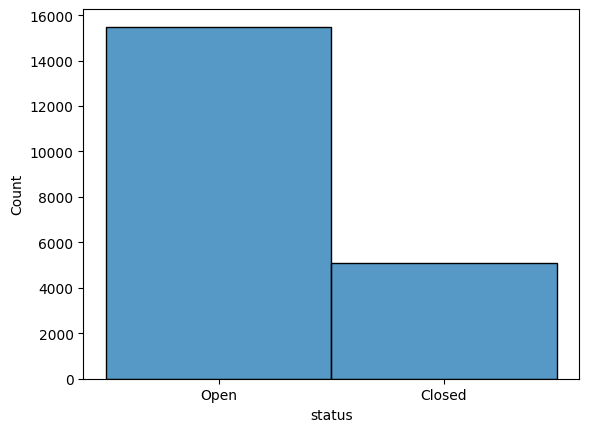

In [ ]:
import seaborn as sns
restaurants["status"] = restaurants["is_open"].map({0: "Closed", 1: "Open"})
sns.histplot(x="status", data=restaurants)


2. Identify and handle missing, duplicate, or inconsistent data

In [ ]:
restaurants.isnull().sum()

,0
business_id,0
name,0
address,0
city,0
state,0
postal_code,0
latitude,0
longitude,0
stars,0
review_count,0


In [ ]:
restaurants["business_id"].duplicated().sum()
#no duplicates

np.int64(0)

<Axes: xlabel='stars', ylabel='Count'>

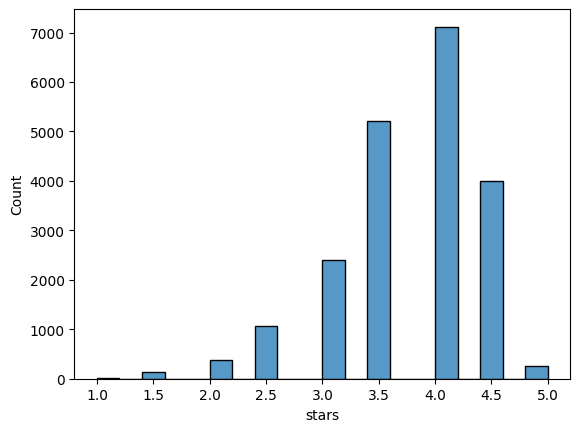

In [ ]:
sns.histplot(restaurants["stars"], bins=20)

Text(0.5, 1.0, 'Distribution of Yelp Star Ratings by Restaurant Status')

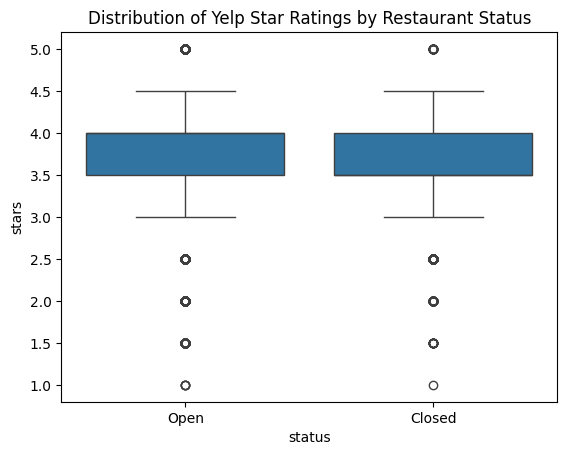

In [ ]:
restaurants["status"] = restaurants["is_open"].map({0: "Closed", 1: "Open"})
sns.boxplot(x="status", y="stars", data=restaurants)
plt.title("Distribution of Yelp Star Ratings by Restaurant Status")

Both open and closed restaurants have a median of 3.5 stars. So Yelp star ratings alone is not a strong way to see if a restaurant stays open

Text(0.5, 1.0, 'Distribution of Yelp Star Ratings by Restaurant Status')

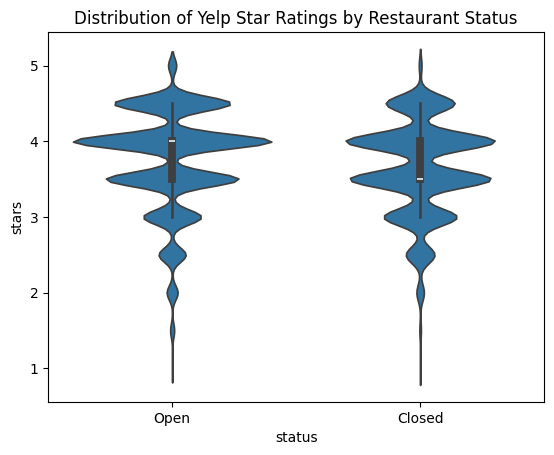

In [ ]:
sns.violinplot(x="status", y="stars", data=restaurants)
plt.title("Distribution of Yelp Star Ratings by Restaurant Status")

In [ ]:
restaurants.groupby("status")["stars"].mean()

,stars
status,
Closed,3.643152
Open,3.765236


Text(0.5, 1.0, 'Average Yelp Star Ratings by Restaurant Status')

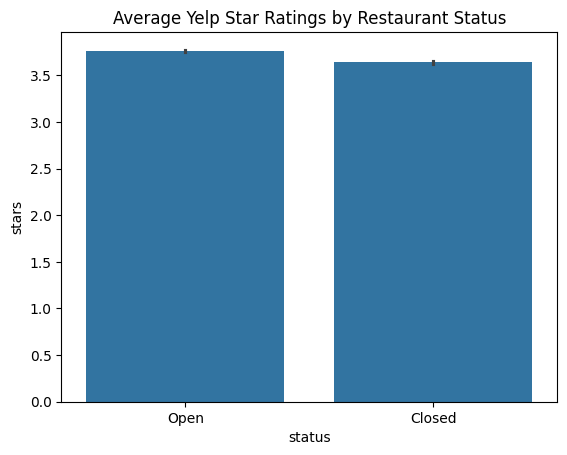

In [ ]:
sns.barplot(x="status", y="stars", data=restaurants)
plt.title("Average Yelp Star Ratings by Restaurant Status")

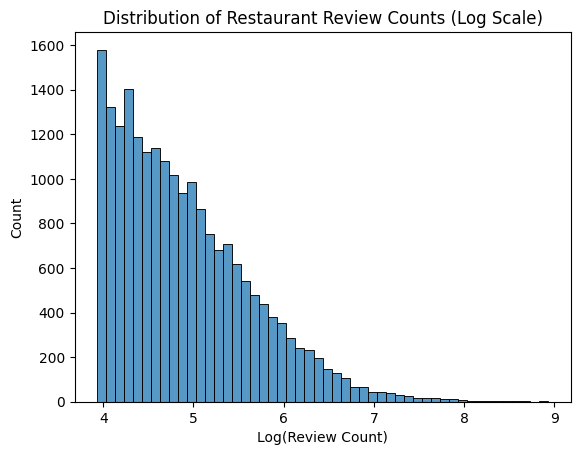

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(np.log1p(restaurants["review_count"]), bins=50)
plt.xlabel("Log(Review Count)")
plt.title("Distribution of Restaurant Review Counts (Log Scale)")
plt.show()

Text(0.5, 1.0, 'Review Count by Restaurant Status')

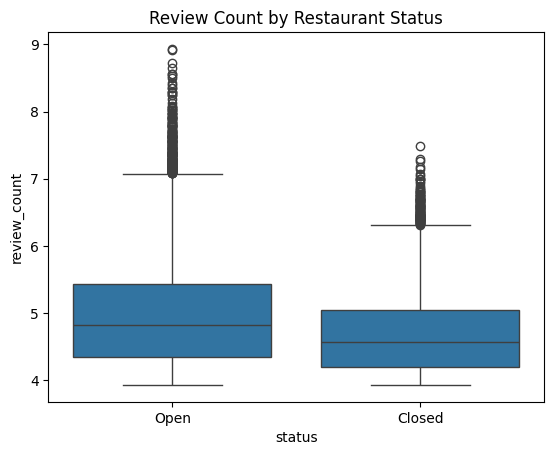

In [ ]:
#do open restaurants have more reviews?
sns.boxplot(x="status", y=np.log1p(restaurants["review_count"]), data=restaurants)
plt.title("Review Count by Restaurant Status")

open restaurants have a higher median review count. (open restaurants have more reviews than closed ones). open restaurants have more high review outliers which can suggest that more popular restaurants can be more likely to be operating.

In [ ]:
restaurants.groupby("status")["review_count"].mean()

,review_count
status,
Closed,136.684179
Open,209.377276


Text(0.5, 1.0, 'Distribution of Review Counts by Restaurant Status')

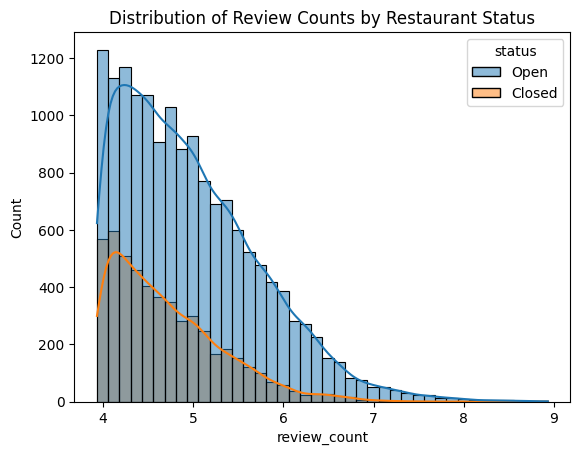

In [ ]:
sns.histplot(data=restaurants, x=np.log1p(restaurants["review_count"]), hue="status", bins=40, kde=True)
plt.title("Distribution of Review Counts by Restaurant Status")

In [ ]:
restaurants[["stars","review_count"]].corr()

,stars,review_count
stars,1.000000,0.135993
review_count,0.135993,1.000000


<Axes: >

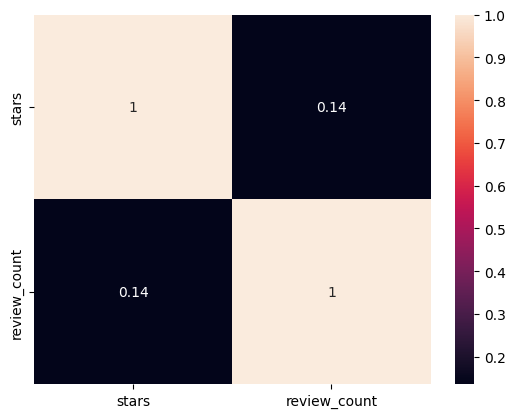

In [ ]:
sns.heatmap(restaurants[["stars","review_count"]].corr(), annot=True)

### Analysis Methods

In [ ]:
## t-test
import numpy as np
from scipy.stats import ttest_ind
restaurants["log_reviews"] = np.log1p(restaurants["review_count"])
open_reviews = restaurants[restaurants["is_open"] == 1]["log_reviews"]
closed_reviews = restaurants[restaurants["is_open"] == 0]["log_reviews"]

ttest_ind(open_reviews, closed_reviews)

TtestResult(statistic=np.float64(22.85895712385208), pvalue=np.float64(3.1503186675855854e-114), df=np.float64(20570.0))

 There is a big difference in review counts between open and closed restaurants -> Open restaurants have significantly higher review counts than closed ones.

 For hyp: More reviews -> more likely to be open

In [ ]:
ttest_ind(
    restaurants[restaurants["is_open"] == 1]["stars"],
    restaurants[restaurants["is_open"] == 0]["stars"]
)

TtestResult(statistic=np.float64(11.938825566546866), pvalue=np.float64(9.528338136377754e-33), df=np.float64(20570.0))

There is a difference in star ratings between open and closed restaurants but the difference is small. So while ratings are different they might not be a string predictor of restaurant operating status.

In [ ]:
## chi-square test
#get categories for restaurants
restaurants["main_category"] = restaurants["categories"].str.split(",").str[0]
#create table for test
#test
from scipy.stats import chi2_contingency
table = pd.crosstab(restaurants["main_category"], restaurants["is_open"])
chi2_contingency(table)

Chi2ContingencyResult(statistic=np.float64(467.89814452799567), pvalue=np.float64(3.7478211375390964e-08), dof=314, expected_freq=array([[2.22331324e+00, 6.77668676e+00],
       [4.94069609e+00, 1.50593039e+01],
       [2.47034805e-01, 7.52965195e-01],
       [4.94069609e-01, 1.50593039e+00],
       [9.88139218e-01, 3.01186078e+00],
       [2.47034805e+00, 7.52965195e+00],
       [2.47034805e-01, 7.52965195e-01],
       [1.56373031e+02, 4.76626969e+02],
       [1.84287964e+02, 5.61712036e+02],
       [2.47034805e-01, 7.52965195e-01],
       [2.47034805e-01, 7.52965195e-01],
       [7.41104414e-01, 2.25889559e+00],
       [7.41104414e-01, 2.25889559e+00],
       [7.41104414e-01, 2.25889559e+00],
       [4.94069609e-01, 1.50593039e+00],
       [4.94069609e-01, 1.50593039e+00],
       [2.47034805e-01, 7.52965195e-01],
       [1.87746451e+01, 5.72253549e+01],
       [4.17488820e+01, 1.27251118e+02],
       [9.88139218e-01, 3.01186078e+00],
       [1.43280187e+01, 4.36719813e+01],
       [3

Null hyp: Restaurant category and is_open are independent.

Results: p-value = 3.7478211375390964e-08 -> extremely small

There is a statistically significant relationship between restaurant category and operating status. Reject null hyp. -> Some restaurant categories are more likely to be open or closed than others.



In [ ]:
from textblob import TextBlob
import pandas as pd
import gc

restaurant_ids = set(restaurants["business_id"])

chunk_results = []

for chunk in pd.read_json(
    "/content/drive/MyDrive/163/yelp_academic_dataset_review.json",
    lines=True,
    chunksize=10000
):
    filtered = chunk[chunk["business_id"].isin(restaurant_ids)].copy()

    if filtered.empty:
        continue

    # compute sentiment
    filtered["sentiment"] = filtered["text"].apply(
        lambda x: TextBlob(str(x)).sentiment.polarity
    )

    # aggregate immediately
    agg_chunk = filtered.groupby("business_id").agg(
        sentiment_sum=("sentiment", "sum"),
        review_n=("sentiment", "size")
    ).reset_index()

    chunk_results.append(agg_chunk)

    # free memory
    del chunk, filtered, agg_chunk
    gc.collect()

# combine all chunks
sentiment_df = pd.concat(chunk_results)

# final aggregation
sentiment_df = sentiment_df.groupby("business_id").agg(
    sentiment_sum=("sentiment_sum", "sum"),
    review_n=("review_n", "sum")
).reset_index()

# compute final average
sentiment_df["avg_sentiment"] = (
    sentiment_df["sentiment_sum"] / sentiment_df["review_n"]
)

# merge into restaurants
restaurants = restaurants.merge(
    sentiment_df[["business_id", "avg_sentiment"]],
    on="business_id",
    how="left"
)

In [ ]:
restaurants["avg_sentiment"].head()

,avg_sentiment
0,0.280990
1,0.294617
2,0.343521
3,0.298164
4,0.134757


In [ ]:
from scipy.stats import ttest_ind

ttest_ind(
    restaurants[restaurants["is_open"] == 1]["avg_sentiment"].dropna(),
    restaurants[restaurants["is_open"] == 0]["avg_sentiment"].dropna()
)

TtestResult(statistic=np.float64(6.967258052344872), pvalue=np.float64(3.329404926366119e-12), df=np.float64(20570.0))

In [ ]:
restaurants.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours,status,log_reviews,main_category,avg_sentiment
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ...",Open,4.394449,Restaurants,0.280990
1,0bPLkL0QhhPO5kt1_EXmNQ,Zio's Italian Market,2575 E Bay Dr,Largo,FL,33771,27.916116,-82.760461,4.5,100,0,"{'OutdoorSeating': 'False', 'RestaurantsGoodFo...","Food, Delis, Italian, Bakeries, Restaurants","{'Monday': '10:0-18:0', 'Tuesday': '10:0-20:0'...",Closed,4.615121,Food,0.294617
2,MUTTqe8uqyMdBl186RmNeA,Tuna Bar,205 Race St,Philadelphia,PA,19106,39.953949,-75.143226,4.0,245,1,"{'RestaurantsReservations': 'True', 'Restauran...","Sushi Bars, Restaurants, Japanese","{'Tuesday': '13:30-22:0', 'Wednesday': '13:30-...",Open,5.505332,Sushi Bars,0.343521
3,ROeacJQwBeh05Rqg7F6TCg,BAP,1224 South St,Philadelphia,PA,19147,39.943223,-75.162568,4.5,205,1,"{'NoiseLevel': 'u'quiet'', 'GoodForMeal': '{'d...","Korean, Restaurants","{'Monday': '11:30-20:30', 'Tuesday': '11:30-20...",Open,5.327876,Korean,0.298164
4,9OG5YkX1g2GReZM0AskizA,Romano's Macaroni Grill,5505 S Virginia St,Reno,NV,89502,39.476117,-119.789339,2.5,339,1,"{'RestaurantsGoodForGroups': 'True', 'Restaura...","Restaurants, Italian","{'Monday': '11:0-22:0', 'Tuesday': '11:0-22:0'...",Open,5.828946,Restaurants,0.134757


Text(0.5, 1.0, 'Average Sentiment by Restaurant Status')

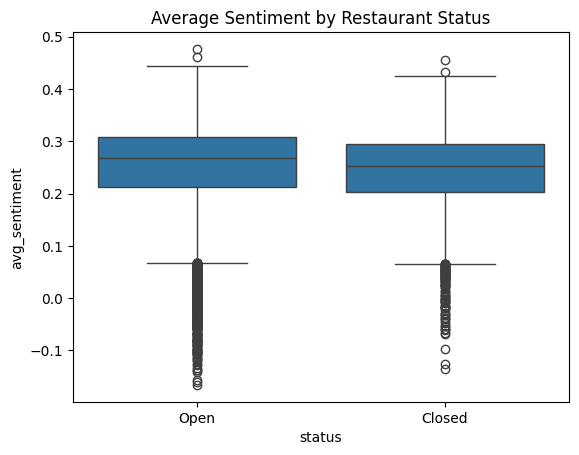

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x="status", y="avg_sentiment", data=restaurants)
plt.title("Average Sentiment by Restaurant Status")

Text(0.5, 1.0, 'Distribution of Average Sentiment by Restaurant Status')

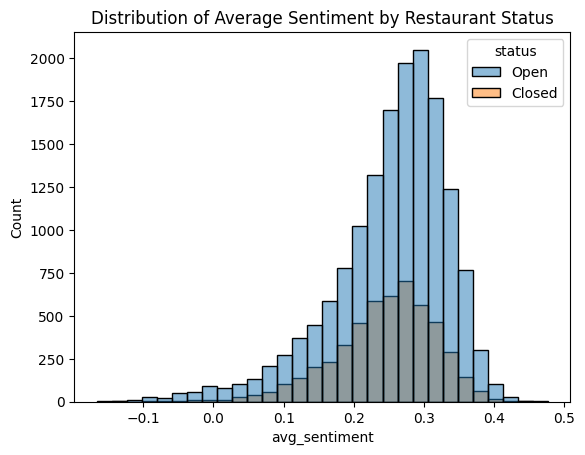

In [ ]:
sns.histplot(data=restaurants, x="avg_sentiment", hue="status", bins=30)
plt.title("Distribution of Average Sentiment by Restaurant Status")


In [ ]:
restaurants[["avg_sentiment","is_open"]].corr()

,avg_sentiment,is_open
avg_sentiment,1.000000,0.048521
is_open,0.048521,1.000000


<Axes: >

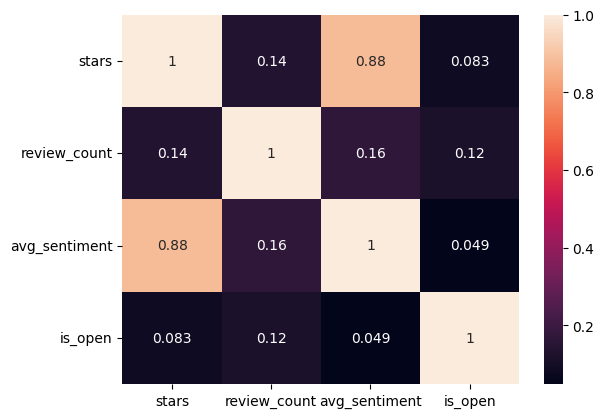

In [ ]:
sns.heatmap(
    restaurants[["stars","review_count","avg_sentiment", "is_open"]].corr(),
    annot=True
)



In [ ]:
import plotly.express as px

fig = px.histogram(
    restaurants,
    x="avg_sentiment",
    color="status",
    nbins=40,
    title="Distribution of Average Sentiment by Restaurant Status",
    opacity=0.6,
    barmode="overlay"
)

fig.show()

In [ ]:
fig = px.scatter(
    restaurants,
    x="stars",
    y="avg_sentiment",
    color="status",
    title="Stars vs Sentiment by Restaurant Status",
    opacity=0.5
)

fig.show()

In [ ]:
fig = px.histogram(
    restaurants,
    x="avg_sentiment",
    color="status",
    marginal="box",
    title="Interactive Sentiment Distribution"
)

fig.show()

## Machine Learning

### Model 1: Review count only

In [ ]:
#ML imports
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler

#choose feature
data = restaurants[["is_open", "log_reviews", "stars", "avg_sentiment"]].dropna()

y = data["is_open"]
X1 = data[["log_reviews"]]

#split into train/test sets
X1_train, X1_test, y_train, y_test = train_test_split(
    X1, y, test_size=0.2, random_state=42, stratify=y
)

#scale features
scaler1 = StandardScaler()
X1_train = scaler1.fit_transform(X1_train)
X1_test = scaler1.transform(X1_test)

#create log reg model
model1 = LogisticRegression(max_iter=1000, class_weight="balanced")

#train model
model1.fit(X1_train, y_train)

#make predictions
pred1 = model1.predict(X1_test)

#get probabilities
prob1 = model1.predict_proba(X1_test)[:, 1]

#evaluate model
print("Model 1")
print("Accuracy:", accuracy_score(y_test, pred1))
print("F1 Score:", f1_score(y_test, pred1))
print("ROC-AUC:", roc_auc_score(y_test, prob1))




Model 1
Accuracy: 0.5436208991494532
F1 Score: 0.6258964143426294
ROC-AUC: 0.6103112802182141


### Model 2: Review count + stars

In [ ]:
#choose feature
X2 = data[["log_reviews", "stars"]]

#split into train/test sets
X2_train, X2_test, y_train, y_test = train_test_split(
    X2, y, test_size=0.2, random_state=42, stratify=y
)

#scale features
scaler2 = StandardScaler()
X2_train = scaler2.fit_transform(X2_train)
X2_test = scaler2.transform(X2_test)

#create log reg model
model2 = LogisticRegression(max_iter=1000, class_weight="balanced")

#train model
model2.fit(X2_train, y_train)

#make predictions
pred2 = model2.predict(X2_test)

#get probabilities
prob2 = model2.predict_proba(X2_test)[:, 1]

#evaluate model
print("Model 2")
print("Accuracy:", accuracy_score(y_test, pred2))
print("F1 Score:", f1_score(y_test, pred2))
print("ROC-AUC:", roc_auc_score(y_test, prob2))



Model 2
Accuracy: 0.5667071688942892
F1 Score: 0.6527750730282376
ROC-AUC: 0.6147454220790144


### Model 3: review count + stars + sentiment

In [ ]:
#choose feature
X3 = data[["log_reviews", "stars", "avg_sentiment"]]

#split into train/test sets
X3_train, X3_test, y_train, y_test = train_test_split(
    X3, y, test_size=0.2, random_state=42, stratify=y
)

#scale features
scaler3 = StandardScaler()
X3_train = scaler3.fit_transform(X3_train)
X3_test = scaler3.transform(X3_test)

#create log reg model
model3 = LogisticRegression(max_iter=1000, class_weight="balanced")

#train model
model3.fit(X3_train, y_train)

#make predictions
pred3 = model3.predict(X3_test)

#get probabilities
prob3 = model3.predict_proba(X3_test)[:, 1]

#evaluate model
print("Model 3")
print("Accuracy:", accuracy_score(y_test, pred3))
print("F1 Score:", f1_score(y_test, pred3))
print("ROC-AUC:", roc_auc_score(y_test, prob3))

Model 3
Accuracy: 0.5708383961117861
F1 Score: 0.6594677979174701
ROC-AUC: 0.627306417119428


Model performance improved as additional features were added. Review count alone provided the strongest baseline, while star ratings contributed a small improvement. Including sentiment resulted in a slight increase in performance, indicating that sentiment provides limited but meaningful additional predictive value.

Although sentiment showed a weak individual relationship with operating status, it contributed modest improvements when combined with other features.

### Model 4: + ubereats features

In [ ]:
import pandas as pd
import numpy as np

ubereats = pd.read_csv("/content/drive/MyDrive/163/ubereats.csv")

ubereats.head()

,id,position,name,score,ratings,category,price_range,full_address,zip_code,lat,lng
0,1,19,PJ Fresh (224 Daniel Payne Drive),NaN,NaN,"Burgers, American, Sandwiches",$,"224 Daniel Payne Drive, Birmingham, AL, 35207",35207,33.562365,-86.830703
1,2,9,J' ti`'z Smoothie-N-Coffee Bar,NaN,NaN,"Coffee and Tea, Breakfast and Brunch, Bubble Tea",NaN,"1521 Pinson Valley Parkway, Birmingham, AL, 35217",35217,33.583640,-86.773330
2,3,6,Philly Fresh Cheesesteaks (541-B Graymont Ave),NaN,NaN,"American, Cheesesteak, Sandwiches, Alcohol",$,"541-B Graymont Ave, Birmingham, AL, 35204",35204,33.509800,-86.854640
3,4,17,Papa Murphy's (1580 Montgomery Highway),NaN,NaN,Pizza,$,"1580 Montgomery Highway, Hoover, AL, 35226",35226,33.404439,-86.806614
4,5,162,Nelson Brothers Cafe (17th St N),4.7,22.0,"Breakfast and Brunch, Burgers, Sandwiches",NaN,"314 17th St N, Birmingham, AL, 35203",35203,33.514730,-86.811700


In [ ]:
ubereats.columns

Index(['id', 'position', 'name', 'score', 'ratings', 'category', 'price_range',
       'full_address', 'zip_code', 'lat', 'lng'],
      dtype='object')

In [ ]:
ubereats = ubereats[[
    "name",
    "score",
    "ratings",
    "price_range",
    "category",
    "zip_code",
    "lat",
    "lng"
]].copy()

In [ ]:
ubereats = ubereats.rename(columns={
    "name": "ubereats_name",
    "score": "ubereats_score",
    "ratings": "ubereats_ratings",
    "category": "ubereats_category",
    "lat": "ubereats_lat",
    "lng": "ubereats_lng"
})

In [ ]:
ubereats.columns

Index(['ubereats_name', 'ubereats_score', 'ubereats_ratings', 'price_range',
       'ubereats_category', 'zip_code', 'ubereats_lat', 'ubereats_lng'],
      dtype='object')

In [ ]:
restaurants.columns

Index(['business_id', 'name', 'address', 'city', 'state', 'postal_code',
       'latitude', 'longitude', 'stars', 'review_count', 'is_open',
       'attributes', 'categories', 'hours', 'status', 'log_reviews',
       'main_category', 'avg_sentiment'],
      dtype='object')

In [ ]:
restaurants = restaurants.rename(columns={"postal_code": "zip_code"})

In [ ]:
yelp = restaurants[[
    "business_id",
    "name",
    "zip_code",
    "stars",
    "review_count",
    "log_reviews",
    "avg_sentiment",
    "is_open"
]].copy()

In [ ]:
import re

def clean_name(name):
    name = str(name).lower()
    name = re.sub(r"[^a-z0-9\s]", "", name)
    name = re.sub(r"\s+", " ", name).strip()
    return name

yelp["clean_name"] = yelp["name"].apply(clean_name)
ubereats["clean_name"] = ubereats["ubereats_name"].apply(clean_name)

yelp["zip_code"] = yelp["zip_code"].astype(str).str[:5]
ubereats["zip_code"] = ubereats["zip_code"].astype(str).str[:5]

merging on zipcode + name resulted in 0 matches -> merge only on name

In [ ]:
merged = yelp.merge(
    ubereats,
    on="clean_name",
    how="left"
)

merged.head()

,business_id,name,zip_code_x,stars,review_count,log_reviews,avg_sentiment,is_open,clean_name,ubereats_name,ubereats_score,ubereats_ratings,price_range,ubereats_category,zip_code_y,ubereats_lat,ubereats_lng
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,19107,4.0,80,4.394449,0.280990,1,st honore pastries,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0bPLkL0QhhPO5kt1_EXmNQ,Zio's Italian Market,33771,4.5,100,4.615121,0.294617,0,zios italian market,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,MUTTqe8uqyMdBl186RmNeA,Tuna Bar,19106,4.0,245,5.505332,0.343521,1,tuna bar,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ROeacJQwBeh05Rqg7F6TCg,BAP,19147,4.5,205,5.327876,0.298164,1,bap,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,9OG5YkX1g2GReZM0AskizA,Romano's Macaroni Grill,89502,2.5,339,5.828946,0.134757,1,romanos macaroni grill,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Delivery presence variable

In [ ]:
merged["delivery_presence"] = merged["ubereats_score"].notna().astype(int)

In [ ]:
merged.tail()

,business_id,name,zip_code_x,stars,review_count,log_reviews,avg_sentiment,is_open,clean_name,ubereats_name,ubereats_score,ubereats_ratings,price_range,ubereats_category,zip_code_y,ubereats_lat,ubereats_lng,delivery_presence
22440,uriD7RFuHhLJeDdKaf0nFA,Pizza Guru,93105,4.0,299,5.703782,0.278261,0,pizza guru,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
22441,-R9t30RvsG-Rtiq63yuEmg,Crescent No Lawyers Bar-Grill,83706,2.5,55,4.025352,0.110657,0,crescent no lawyers bargrill,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
22442,wVxXRFf10zTTAs11nr4xeA,PrimoHoagies,19128,3.0,55,4.025352,0.185567,1,primohoagies,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
22443,2MAQeAqmD8enCT2ZYqUgIQ,The Melting Pot - Nashville,37201,4.0,204,5.323010,0.301174,0,the melting pot nashville,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
22444,w_4xUt-1AyY2ZwKtnjW0Xg,Bittercreek Alehouse,83702,4.5,998,6.906755,0.362970,1,bittercreek alehouse,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [ ]:
merged["delivery_presence"].value_counts()

,count
delivery_presence,
0,20261
1,2184


In [ ]:
merged["delivery_presence"].mean()

np.float64(0.09730452216529294)

In [ ]:
merged["ubereats_score"] = merged["ubereats_score"].fillna(0)
merged["ubereats_ratings"] = merged["ubereats_ratings"].fillna(0)
price_map = {"$":1, "$$":2, "$$$":3, "$$$$":4}
merged["price_level"] = merged["price_range"].map(price_map).fillna(0)

In [ ]:
merged.head()

,business_id,name,zip_code_x,stars,review_count,log_reviews,avg_sentiment,is_open,clean_name,ubereats_name,ubereats_score,ubereats_ratings,price_range,ubereats_category,zip_code_y,ubereats_lat,ubereats_lng,delivery_presence,price_level
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,19107,4.0,80,4.394449,0.280990,1,st honore pastries,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0,0.0
1,0bPLkL0QhhPO5kt1_EXmNQ,Zio's Italian Market,33771,4.5,100,4.615121,0.294617,0,zios italian market,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0,0.0
2,MUTTqe8uqyMdBl186RmNeA,Tuna Bar,19106,4.0,245,5.505332,0.343521,1,tuna bar,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0,0.0
3,ROeacJQwBeh05Rqg7F6TCg,BAP,19147,4.5,205,5.327876,0.298164,1,bap,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0,0.0
4,9OG5YkX1g2GReZM0AskizA,Romano's Macaroni Grill,89502,2.5,339,5.828946,0.134757,1,romanos macaroni grill,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0,0.0


In [ ]:
merged["business_id"].duplicated().sum()

np.int64(1873)

In [ ]:
merged = merged.drop_duplicates(subset="business_id")

In [ ]:
X4 = merged[[
    "log_reviews",
    "stars",
    "avg_sentiment",
    "delivery_presence",
    "ubereats_score",
    "ubereats_ratings",
    "price_level"
]].dropna()

y4 = merged["is_open"]

In [ ]:
#split into train/test sets
X4_train, X4_test, y_train, y_test = train_test_split(
    X4, y4, test_size=0.2, random_state=42, stratify=y4
)

#scale features
scaler4 = StandardScaler()
X4_train = scaler4.fit_transform(X4_train)
X4_test = scaler4.transform(X4_test)

#create log reg model
model4 = LogisticRegression(max_iter=1000, class_weight="balanced")

#train model
model4.fit(X4_train, y_train)

#make predictions
pred4 = model4.predict(X4_test)

#get probabilities
prob4 = model4.predict_proba(X4_test)[:, 1]

#evaluate model
print("Model 4")
print("Accuracy:", accuracy_score(y_test, pred4))
print("F1 Score:", f1_score(y_test, pred4))
print("ROC-AUC:", roc_auc_score(y_test, prob4))

Model 4
Accuracy: 0.5701093560145808
F1 Score: 0.6584282680054064
ROC-AUC: 0.6310272177374561


Incorporating UberEats features resulted in a slight improvement in ROC-AUC, indicating a slight increase in the model’s ability to distinguish between open and closed restaurants. However, accuracy and F1 score stayed basically the same, suggesting that delivery platform features provide limited additional predictive value beyond Yelp-based features.

The relatively small improvement may be due to the limited overlap between Yelp and UberEats datasets, as only a subset of restaurants could be matched across platforms.